<a href="https://colab.research.google.com/github/chaehyeonkim-lab/bioinformatics1/blob/main/Binformatics_term_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# LIN28A가 결합하지만 번역 억제를 받지 않는 ER-associated mRNA 후보 탐색

논문에서의 흐름은 다음과 같다.

LIN28A가 mRNA에 결합한다. 특히 ER/membrane/secretory 관련 mRNA에 많이 결합하는데, 이들은 LIN28A을 knockdown한 경우 ribosome의 density가 증가하는 경향성을 보였다. 따라서 LIN28A는 ER-associated translation을 억제한다.

하지만 여기에는 분명히 예외가 존재한다.

LIN28A가 결합하는 ER-associated mRNA임에도 불구하고, Lin28a knockdown 후 ribosome density가 증가하지 않는 mRNA는 실제로 논문의 Figure 5.B에서도 확인 가능하다.


다음과 같이 그룹을 분류 가능하다.

LIN28A-bound ER mRNA
- CLIP enrichment가 높음
- localization annotation상 ER/membrane/secretory 관련

  1. Suppressed ER target
   - LIN28A-bound ER mRNA
   - Lin28a knockdown 후 ribosome density 증가
   - 원래 LIN28A가 번역을 억제했을 가능성이 높음

  2. Escapee ER target
   - LIN28A-bound ER mRNA
   - Lin28a knockdown 후 ribosome density가 증가하지 않음
   - LIN28A가 붙었지만 번역 억제 효과가 뚜렷하지 않음

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!git clone https://github.com/hyeshik/colab-biolab.git
!cd colab-biolab && bash tools/setup.sh
exec(open('colab-biolab/tools/activate_conda.py').read())

Cloning into 'colab-biolab'...
remote: Enumerating objects: 76, done.
remote: Counting objects: 100% (76/76), done.
remote: Compressing objects: 100% (47/47), done.
remote: Total 76 (delta 26), reused 59 (delta 15), pack-reused 0 (from 0)
Receiving objects: 100% (76/76), 318.16 KiB | 3.74 MiB/s, done.
Resolving deltas: 100% (26/26), done.
./
./root/
./root/.profile
./root/.tmux.conf
./root/.condarc
./root/.bashrc.biolab
./root/.bin.priority/
./root/.bin.priority/pip2
./root/.bin.priority/pip3
./root/.bin.priority/pip
./root/.vimrc
--2026-06-08 14:01:19--  https://repo.anaconda.com/miniconda/Miniconda3-latest-Linux-x86_64.sh
Resolving repo.anaconda.com (repo.anaconda.com)... 104.16.32.241, 104.16.191.158, 2606:4700::6810:20f1, ...
Connecting to repo.anaconda.com (repo.anaconda.com)|104.16.32.241|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 163179296 (156M) [application/octet-stream]
Saving to: ‘miniconda3.sh’

miniconda3.sh       100%[===================>] 1

In [ ]:
!ls -al /content/drive/MyDrive/binfo1-datapack1/

total 7162852
-r-------- 1 root root 1370036258 Apr 27  2023 CLIP-35L33G.bam
-r-------- 1 root root    3118336 Apr 27  2023 CLIP-35L33G.bam.bai
-r-------- 1 root root       7113 May 11  2023 CLIP-let7g.bam
-r-------- 1 root root      14561 May 11  2023 CLIP-let7g-gene.pileup
-r-------- 1 root root    2685065 May 11  2023 CLIP-let7g.pileup
-r-------- 1 root root  883334756 Apr 27  2023 gencode.gtf
-r-------- 1 root root   24065406 Apr 27  2023 read-counts.txt
-r-------- 1 root root        751 Apr 27  2023 read-counts.txt.summary
-r-------- 1 root root 1003658801 Apr 27  2023 RNA-control.bam
-r-------- 1 root root    2276104 Apr 27  2023 RNA-control.bam.bai
-r-------- 1 root root 1260991122 Apr 27  2023 RNA-siLin28a.bam
-r-------- 1 root root    2710744 Apr 27  2023 RNA-siLin28a.bam.bai
-r-------- 1 root root  981684502 Apr 27  2023 RNA-siLuc.bam
-r-------- 1 root root    2606104 Apr 27  2023 RNA-siLuc.bam.bai
-r-------- 1 root root  737352902 Apr 27  2023 RPF-siLin28a.bam
-r-------- 1 r

In [ ]:
!conda tos accept --override-channels --channel https://repo.anaconda.com/pkgs/main
!conda tos accept --override-channels --channel https://repo.anaconda.com/pkgs/r
!conda install -y subread

accepted Terms of Service for https://repo.anaconda.com/pkgs/main
accepted Terms of Service for https://repo.anaconda.com/pkgs/r
Jupyter detected...
2 channel Terms of Service accepted
Retrieving notices: - \ done
Channels:
 - conda-forge
 - bioconda
 - defaults
Platform: linux-64
Solving environment: - \ done


==> WARNING: A newer version of conda exists. <==
    current version: 26.3.2
    latest version: 26.5.2

Please update conda by running

    $ conda update -n base -c defaults conda



## Package Plan ##

  environment location: /root/conda

  added / updated specs:
    - subread


The following packages will be downloaded:

    package                    |            build
    ---------------------------|-----------------
    ca-certificates-2026.5.20  |       hbd8a1cb_0         127 KB  conda-forge
    certifi-2026.5.20          |     pyhd8ed1ab_0         131 KB  conda-forge
    conda-26.3.2               |  py313h78bf25f_1         1.2 MB  conda-forge
    openssl-3.6.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu

In [ ]:
from pathlib import Path
import numpy as np
import pandas as pd

DATA_DIR = Path("/content/drive/MyDrive/binfo1-datapack1")
OUT_DIR = Path("/content/drive/MyDrive/BIlecture1/project_outcomes")
OUT_DIR.mkdir(parents=True, exist_ok=True)

COUNT_FILE = DATA_DIR / "read-counts.txt"

CLIP_COL = "CLIP-35L33G.bam"
RNA_CONTROL_COL = "RNA-control.bam"
RNA_CTRL_COL = "RNA-siLuc.bam"
RNA_KD_COL = "RNA-siLin28a.bam"
RPF_CTRL_COL = "RPF-siLuc.bam"
RPF_KD_COL = "RPF-siLin28a.bam"

count_cols = [
    CLIP_COL,
    RNA_CONTROL_COL,
    RNA_CTRL_COL,
    RNA_KD_COL,
    RPF_CTRL_COL,
    RPF_KD_COL,
]

RNA_MIN = 30
RPF_MIN = 80
PSEUDO_CPM = 0.1

if not COUNT_FILE.exists():
    raise FileNotFoundError(
        f"{COUNT_FILE}가 없습니다. Google Drive 공유 폴더를 "
        "MyDrive/binfo1-datapack1 위치에 바로가기/복사한 뒤 다시 실행하세요."
    )

cnts = pd.read_csv(COUNT_FILE, sep="	", comment="#")

if "Geneid" in cnts.columns:
    cnts = cnts.set_index("Geneid")

missing_cols = [c for c in count_cols if c not in cnts.columns]
if missing_cols:
    raise ValueError(f"read-counts.txt에 다음 column이 없습니다: {missing_cols}")

cnts[count_cols] = cnts[count_cols].apply(pd.to_numeric, errors="coerce").fillna(0)

library_sizes = cnts[count_cols].sum(axis=0)
print("Library sizes")
display(library_sizes.to_frame(name="total_counts"))

cpm = cnts[count_cols].div(library_sizes, axis=1) * 1_000_000
cpm = cpm.add_suffix("_cpm")

df = pd.concat([cnts, cpm], axis=1)

# 논문 기준에 가깝게 low-count transcript 제거
# RNA는 abundance와 density 계산 모두에 들어가므로 세 RNA library에서 최소 read 수를 둡니다.
# RPF는 최소한 control footprint가 충분해야 density 변화 해석이 안정적입니다.
keep = (
    (df[RNA_CONTROL_COL] >= RNA_MIN) &
    (df[RNA_CTRL_COL] >= RNA_MIN) &
    (df[RNA_KD_COL] >= RNA_MIN) &
    (df[RPF_CTRL_COL] >= RPF_MIN)
)

df = df.loc[keep].copy()

# LIN28A CLIP enrichment
df["clip_log2"] = np.log2(
    (df[f"{CLIP_COL}_cpm"] + PSEUDO_CPM) /
    (df[f"{RNA_CONTROL_COL}_cpm"] + PSEUDO_CPM)
)

# Ribosome density는 RPF/RNA의 log2 ratio로 먼저 계산합니다.
df["rden_siLuc_log2"] = np.log2(
    (df[f"{RPF_CTRL_COL}_cpm"] + PSEUDO_CPM) /
    (df[f"{RNA_CTRL_COL}_cpm"] + PSEUDO_CPM)
)

df["rden_siLin28a_log2"] = np.log2(
    (df[f"{RPF_KD_COL}_cpm"] + PSEUDO_CPM) /
    (df[f"{RNA_KD_COL}_cpm"] + PSEUDO_CPM)
)

# Lin28a knockdown 후 ribosome density 변화
# 양수: knockdown 후 ribosome density 증가
# 음수: knockdown 후 ribosome density 감소
df["rden_log2"] = df["rden_siLin28a_log2"] - df["rden_siLuc_log2"]

# 기존 코드와의 호환을 위해 ratio scale도 보관
df["rden_siLuc"] = 2 ** df["rden_siLuc_log2"]
df["rden_siLin28a"] = 2 ** df["rden_siLin28a_log2"]

# mRNA abundance 변화
df["rna_change_log2"] = np.log2(
    (df[f"{RNA_KD_COL}_cpm"] + PSEUDO_CPM) /
    (df[f"{RNA_CTRL_COL}_cpm"] + PSEUDO_CPM)
)

df = df.replace([np.inf, -np.inf], np.nan)
df = df.dropna(subset=["clip_log2", "rden_log2", "rna_change_log2"])

print("분석에 남은 gene 수:", len(df))
print("Output directory:", OUT_DIR)

df[
    [
        "Length",
        "clip_log2",
        "rden_siLuc_log2",
        "rden_siLin28a_log2",
        "rden_log2",
        "rna_change_log2",
    ]
].head()


In [ ]:
from pathlib import Path
from urllib.request import urlretrieve
import pandas as pd

LOCALIZATION_URL = "https://hyeshik.qbio.io/binfo/mouselocalization-20210507.txt"
LOCALIZATION_FILE = Path("mouselocalization-20210507.txt")

if not LOCALIZATION_FILE.exists():
    urlretrieve(LOCALIZATION_URL, LOCALIZATION_FILE)

local = pd.read_csv(LOCALIZATION_FILE, sep="	")
local.head()


In [ ]:
from pathlib import Path
import pandas as pd

GTF_FILE = Path("/content/drive/MyDrive/binfo1-datapack1/gencode.gtf")

def parse_gtf_attributes(attr_text):
    result = {}
    for item in attr_text.strip().split(";"):
        item = item.strip()
        if not item:
            continue
        if " " not in item:
            continue
        key, value = item.split(" ", 1)
        result[key] = value.strip().strip('"')
    return result

records = []

with open(GTF_FILE) as f:
    for line in f:
        if line.startswith("#"):
            continue

        parts = line.rstrip("\n").split("\t")
        if len(parts) < 9:
            continue

        feature = parts[2]
        if feature != "gene":
            continue

        attrs = parse_gtf_attributes(parts[8])

        gene_id = attrs.get("gene_id", "")
        gene_id_base = gene_id.split(".")[0]

        records.append(
            {
                "gene_id_base": gene_id_base,
                "gene_name_gtf": attrs.get("gene_name", ""),
                "gene_type": attrs.get("gene_type", attrs.get("gene_biotype", "")),
            }
        )

gtf_gene = pd.DataFrame(records).drop_duplicates("gene_id_base")

print(gtf_gene.shape)
gtf_gene.head()

(55359, 3)


,gene_id_base,gene_name_gtf,gene_type
0,ENSMUSG00000102693,4933401J01Rik,TEC
1,ENSMUSG00000064842,Gm26206,snRNA
2,ENSMUSG00000051951,Xkr4,protein_coding
3,ENSMUSG00000102851,Gm18956,processed_pseudogene
4,ENSMUSG00000103377,Gm37180,TEC


In [ ]:
# df: read-counts.txt에서 계산한 expression / CLIP / RPF 지표
# local: mouselocalization-20210507.txt
# gtf_gene: gencode.gtf에서 추출한 gene_name_gtf, gene_type

merged = df.copy().reset_index()

# reset_index 후 첫 번째 column이 gene id입니다.
merged = merged.rename(columns={merged.columns[0]: "gene_id_count"})

# version 제거: ENSMUSG00000000001.4 -> ENSMUSG00000000001
merged["gene_id_base"] = (
    merged["gene_id_count"]
    .astype(str)
    .str.replace(r"\.\d+$", "", regex=True)
)

# GTF annotation merge
merged = merged.merge(gtf_gene, on="gene_id_base", how="left")

# localization annotation 정리
local2 = local.copy()

local2["gene_id_base"] = (
    local2["gene_id"]
    .astype(str)
    .str.replace(r"\.\d+$", "", regex=True)
)

local2 = (
    local2
    .groupby("gene_id_base", as_index=False)
    .agg(
        {
            "Gene names": lambda x: "; ".join(sorted(set(x.dropna().astype(str)))),
            "type": lambda x: "; ".join(sorted(set(x.dropna().astype(str)))),
        }
    )
)

merged = merged.merge(local2, on="gene_id_base", how="left")

# gene symbol은 GTF를 우선 사용하고, 없으면 localization 파일의 첫 번째 이름 사용
merged["gene_symbol"] = merged["gene_name_gtf"]

fallback_symbol = (
    merged["Gene names"]
    .fillna("")
    .astype(str)
    .str.split(r"\s+|;")
    .str[0]
)

merged.loc[merged["gene_symbol"].isna() | (merged["gene_symbol"] == ""), "gene_symbol"] = fallback_symbol

print("전체 gene 수:", len(merged))
print("GTF gene_name이 붙은 gene 수:", merged["gene_name_gtf"].notna().sum())
print("localization annotation이 붙은 gene 수:", merged["type"].notna().sum())
print("localization annotation이 없는 gene 수:", merged["type"].isna().sum())

merged[
    [
        "gene_id_count",
        "gene_symbol",
        "gene_type",
        "Gene names",
        "type",
        "clip_log2",
        "rden_log2",
        "rna_change_log2",
    ]
].head()

전체 gene 수: 7987
GTF gene_name이 붙은 gene 수: 7987
localization annotation이 붙은 gene 수: 4492
localization annotation이 없는 gene 수: 3495


,gene_id_count,gene_symbol,gene_type,Gene names,type,clip_log2,rden_log2,rna_change_log2
0,ENSMUSG00000033845.14,Mrpl15,protein_coding,NaN,NaN,0.176614,-0.402947,-0.102136
1,ENSMUSG00000033813.16,Tcea1,protein_coding,NaN,NaN,-0.268288,-0.214362,-0.402595
2,ENSMUSG00000033793.13,Atp6v1h,protein_coding,NaN,NaN,-0.160983,-0.578061,-0.050419
3,ENSMUSG00000025907.15,Rb1cc1,protein_coding,Rb1cc1 Cc1 Kiaa0203,nucleus,1.049118,0.069862,-0.718631
4,ENSMUSG00000051285.18,Pcmtd1,protein_coding,Pcmtd1,cytoplasm,1.338382,0.788928,0.071083


In [ ]:
# 현재 mouselocalization 파일의 type은 주로
# 'cytoplasm', 'nucleus', 'integral membrane' 수준입니다.
# 따라서 이 분석에서 ER-associated를 직접 부르는 대신
# integral membrane을 ER-associated translation의 proxy로 사용합니다.

merged['er_proxy'] = (
    merged['type']
    .fillna('')
    .astype(str)
    .str.contains(r'\bintegral membrane\b', case=False, regex=True)
)

print(merged['er_proxy'].value_counts())

merged.loc[
    merged['er_proxy'],
    ['gene_id_count', 'Gene names', 'type', 'clip_log2', 'rden_log2', 'rna_change_log2']
].head(20)

print(merged['er_proxy'].value_counts())

merged.loc[
    merged['er_proxy'],
    ['gene_id_count', 'Gene names', 'type']
].head(20)

er_proxy
False    6934
True     1053
Name: count, dtype: int64
er_proxy
False    6934
True     1053
Name: count, dtype: int64


,gene_id_count,Gene names,type
23,ENSMUSG00000025931.16,Paqr8 Mprb,integral membrane
33,ENSMUSG00000073725.9,Lmbrd1,integral membrane
38,ENSMUSG00000026131.21,Dst Bpag1 Macf2,integral membrane
41,ENSMUSG00000037503.13,Fam168b Kiaa4042,integral membrane
42,ENSMUSG00000026123.12,Plekhb2 Evt2,integral membrane
43,ENSMUSG00000045216.8,Hs6st1,integral membrane
46,ENSMUSG00000001143.14,Lman2l Vipl,integral membrane
47,ENSMUSG00000037408.11,Cnnm4 Acdp4 Kiaa1592,integral membrane
48,ENSMUSG00000001138.14,Cnnm3 Acdp3,integral membrane
52,ENSMUSG00000026116.12,Tmem131 D1Bwg0491e Kiaa0257 Rw1,integral membrane


In [ ]:
import numpy as np

# -----------------------------
# Thresholds
# -----------------------------
CLIP_Q = 0.90                 # 현재 노트북 기준 유지: 상위 10%
RNA_CHANGE_MIN = -0.5         # mRNA abundance가 0.71배 이상 유지
SUPPRESSED_CUTOFF = 0.5       # log2 scale; 약 1.41배 이상 ribosome density 증가
ESCAPEE_CUTOFF = 0.0          # 증가 없음

# 분석 대상으로 삼을 gene
# protein_coding 정보가 없을 수도 있으므로, gene_type이 비어 있으면 일단 포함합니다.
analysis_base = (
    merged["clip_log2"].notna() &
    merged["rden_log2"].notna() &
    merged["rna_change_log2"].notna()
)

if "gene_type" in merged.columns:
    analysis_base = analysis_base & (
        merged["gene_type"].isna() |
        (merged["gene_type"] == "") |
        (merged["gene_type"] == "protein_coding")
    )

# histone mRNA는 poly(A) 문제 때문에 원 논문에서도 주의 대상입니다.
# gene_symbol이 있는 경우 Hist로 시작하는 gene을 제외합니다.
not_histone = ~merged["gene_symbol"].fillna("").str.startswith("Hist")
analysis_base = analysis_base & not_histone

clip_cutoff = merged.loc[analysis_base, "clip_log2"].quantile(CLIP_Q)

print("LIN28A strong binding cutoff:", clip_cutoff)

strong_binding = merged["clip_log2"] >= clip_cutoff
er_proxy = merged["er_proxy"]
rna_not_decreased = merged["rna_change_log2"] >= RNA_CHANGE_MIN

translation_derepressed = merged["rden_log2"] >= SUPPRESSED_CUTOFF
translation_escapee = merged["rden_log2"] <= ESCAPEE_CUTOFF

candidate_base = analysis_base & strong_binding & er_proxy & rna_not_decreased

merged["target_class"] = "Other"

merged.loc[
    candidate_base,
    "target_class"
] = "LIN28A-bound ER-proxy intermediate"

merged.loc[
    candidate_base & translation_derepressed,
    "target_class"
] = "Suppressed-like ER target"

merged.loc[
    candidate_base & translation_escapee,
    "target_class"
] = "Escapee ER target"

merged["target_class"].value_counts()

LIN28A strong binding cutoff: 0.9805813164977287


,count
target_class,
Other,7735
Suppressed-like ER target,157
LIN28A-bound ER-proxy intermediate,86
Escapee ER target,9


In [ ]:
def classify_with_thresholds(
    data,
    clip_q=0.90,
    rna_change_min=-0.5,
    suppressed_cutoff=0.5,
    escapee_cutoff=0.0,
):
    base = (
        data["clip_log2"].notna() &
        data["rden_log2"].notna() &
        data["rna_change_log2"].notna()
    )

    if "gene_type" in data.columns:
        base = base & (
            data["gene_type"].isna() |
            (data["gene_type"] == "") |
            (data["gene_type"] == "protein_coding")
        )

    base = base & ~data["gene_symbol"].fillna("").str.startswith("Hist")

    cutoff = data.loc[base, "clip_log2"].quantile(clip_q)

    strong = data["clip_log2"] >= cutoff
    er = data["er_proxy"]
    rna_ok = data["rna_change_log2"] >= rna_change_min

    cand = base & strong & er & rna_ok
    suppressed = cand & (data["rden_log2"] >= suppressed_cutoff)
    escapee = cand & (data["rden_log2"] <= escapee_cutoff)
    intermediate = cand & ~(suppressed | escapee)

    return {
        "clip_q": clip_q,
        "clip_cutoff": cutoff,
        "candidate_base": int(cand.sum()),
        "suppressed": int(suppressed.sum()),
        "escapee": int(escapee.sum()),
        "intermediate": int(intermediate.sum()),
    }

sensitivity = pd.DataFrame(
    [
        classify_with_thresholds(merged, clip_q=q)
        for q in [0.80, 0.90, 0.95]
    ]
)

sensitivity

,clip_q,clip_cutoff,candidate_base,suppressed,escapee,intermediate
0,0.80,0.398461,430,233,26,171
1,0.90,0.980581,252,157,9,86
2,0.95,1.401439,141,98,4,39


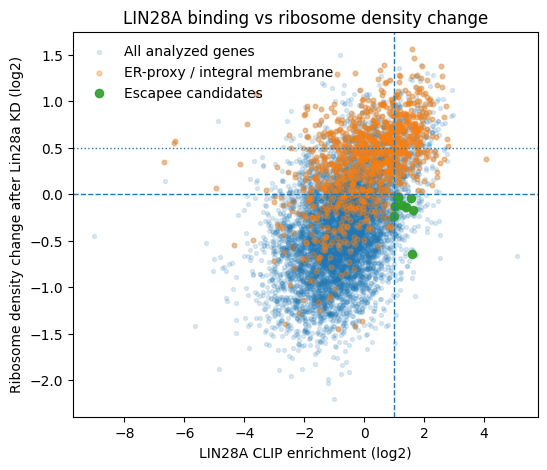

All genes Pearson r, p: PearsonRResult(statistic=np.float64(0.4878989084908113), pvalue=np.float64(0.0))
All genes Spearman rho, p: SignificanceResult(statistic=np.float64(0.4808637376643336), pvalue=np.float64(0.0))


In [ ]:
import matplotlib.pyplot as plt
from scipy import stats

plot_df = merged.loc[analysis_base].copy()

fig, ax = plt.subplots(figsize=(6, 5))

# 전체 gene
ax.scatter(
    plot_df["clip_log2"],
    plot_df["rden_log2"],
    s=8,
    alpha=0.15,
    label="All analyzed genes",
)

# ER proxy gene
er_df = plot_df[plot_df["er_proxy"]]
ax.scatter(
    er_df["clip_log2"],
    er_df["rden_log2"],
    s=12,
    alpha=0.35,
    label="ER-proxy / integral membrane",
)

# Escapee 후보
escapee_df = plot_df[plot_df["target_class"] == "Escapee ER target"]
ax.scatter(
    escapee_df["clip_log2"],
    escapee_df["rden_log2"],
    s=35,
    alpha=0.9,
    label="Escapee candidates",
)

ax.axvline(clip_cutoff, linestyle="--", linewidth=1)
ax.axhline(0, linestyle="--", linewidth=1)
ax.axhline(SUPPRESSED_CUTOFF, linestyle=":", linewidth=1)

ax.set_xlabel("LIN28A CLIP enrichment (log2)")
ax.set_ylabel("Ribosome density change after Lin28a KD (log2)")
ax.set_title("LIN28A binding vs ribosome density change")
ax.legend(frameon=False)

plt.show()

pearson_all = stats.pearsonr(plot_df["clip_log2"], plot_df["rden_log2"])
spearman_all = stats.spearmanr(plot_df["clip_log2"], plot_df["rden_log2"])

print("All genes Pearson r, p:", pearson_all)
print("All genes Spearman rho, p:", spearman_all)

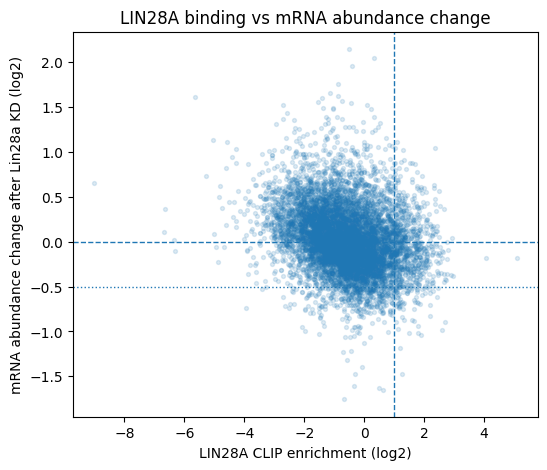

CLIP vs RNA change Pearson r, p: PearsonRResult(statistic=np.float64(-0.2716938280225777), pvalue=np.float64(1.0088954694998892e-132))
CLIP vs RNA change Spearman rho, p: SignificanceResult(statistic=np.float64(-0.2949602499622127), pvalue=np.float64(3.686125606584136e-157))


In [ ]:
fig, ax = plt.subplots(figsize=(6, 5))

ax.scatter(
    plot_df["clip_log2"],
    plot_df["rna_change_log2"],
    s=8,
    alpha=0.15,
)

ax.axvline(clip_cutoff, linestyle="--", linewidth=1)
ax.axhline(0, linestyle="--", linewidth=1)
ax.axhline(RNA_CHANGE_MIN, linestyle=":", linewidth=1)

ax.set_xlabel("LIN28A CLIP enrichment (log2)")
ax.set_ylabel("mRNA abundance change after Lin28a KD (log2)")
ax.set_title("LIN28A binding vs mRNA abundance change")

plt.show()

pearson_rna = stats.pearsonr(plot_df["clip_log2"], plot_df["rna_change_log2"])
spearman_rna = stats.spearmanr(plot_df["clip_log2"], plot_df["rna_change_log2"])

print("CLIP vs RNA change Pearson r, p:", pearson_rna)
print("CLIP vs RNA change Spearman rho, p:", spearman_rna)

In [ ]:
from scipy import stats
import numpy as np
import pandas as pd

corr_df = merged.loc[
    analysis_base,
    ["clip_log2", "rden_log2", "rna_change_log2", "er_proxy", "target_class"]
].dropna().copy()

def corr_summary(x, y, label):
    pearson = stats.pearsonr(corr_df[x], corr_df[y])
    spearman = stats.spearmanr(corr_df[x], corr_df[y])

    return {
        "comparison": label,
        "n": len(corr_df),
        "pearson_r": pearson.statistic,
        "pearson_p": pearson.pvalue,
        "pearson_R2": pearson.statistic ** 2,
        "spearman_rho": spearman.statistic,
        "spearman_p": spearman.pvalue,
    }

corr_table = pd.DataFrame(
    [
        corr_summary(
            "clip_log2",
            "rden_log2",
            "LIN28A binding vs ribosome density change",
        ),
        corr_summary(
            "clip_log2",
            "rna_change_log2",
            "LIN28A binding vs mRNA abundance change",
        ),
    ]
)

display(corr_table)
corr_table.to_csv(OUT_DIR / "correlation_summary.tsv", sep="\t", index=False)

,comparison,n,pearson_r,pearson_p,pearson_R2,spearman_rho,spearman_p
0,LIN28A binding vs ribosome density change,7840,0.487899,0.000000e+00,0.238045,0.480864,0.000000e+00
1,LIN28A binding vs mRNA abundance change,7840,-0.271694,1.008895e-132,0.073818,-0.294960,3.686126e-157


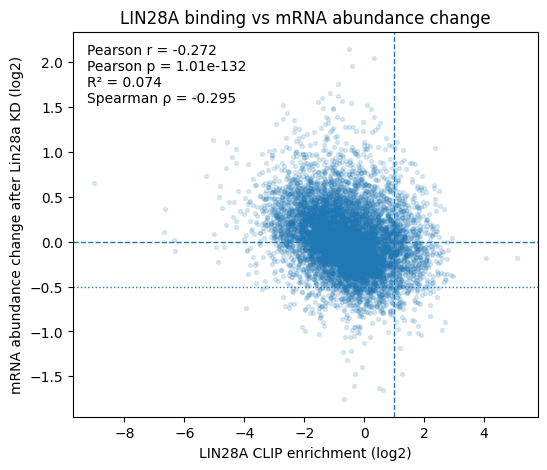

In [ ]:
import matplotlib.pyplot as plt
from scipy import stats

plot_df = merged.loc[analysis_base].dropna(
    subset=["clip_log2", "rna_change_log2"]
).copy()

pearson = stats.pearsonr(plot_df["clip_log2"], plot_df["rna_change_log2"])
spearman = stats.spearmanr(plot_df["clip_log2"], plot_df["rna_change_log2"])

fig, ax = plt.subplots(figsize=(6, 5))

ax.scatter(
    plot_df["clip_log2"],
    plot_df["rna_change_log2"],
    s=8,
    alpha=0.15,
)

ax.axvline(clip_cutoff, linestyle="--", linewidth=1)
ax.axhline(0, linestyle="--", linewidth=1)
ax.axhline(RNA_CHANGE_MIN, linestyle=":", linewidth=1)

ax.set_xlabel("LIN28A CLIP enrichment (log2)")
ax.set_ylabel("mRNA abundance change after Lin28a KD (log2)")
ax.set_title("LIN28A binding vs mRNA abundance change")

annotation = (
    f"Pearson r = {pearson.statistic:.3f}\n"
    f"Pearson p = {pearson.pvalue:.2e}\n"
    f"R² = {pearson.statistic ** 2:.3f}\n"
    f"Spearman ρ = {spearman.statistic:.3f}"
)

ax.text(
    0.03,
    0.97,
    annotation,
    transform=ax.transAxes,
    va="top",
)

fig.savefig(
    OUT_DIR / "clip_vs_rna_change.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

위의 plot은 LIN28A binding이 RNA abundance 변화와 강하게 연결되어 있지 않다는 점을 보여줌

In [ ]:
out_cols = [
    "gene_id_count",
    "gene_id_base",
    "gene_symbol",
    "gene_type",
    "Gene names",
    "type",
    "Length",
    "clip_log2",
    "rden_siLuc_log2",
    "rden_siLin28a_log2",
    "rden_log2",
    "rna_change_log2",
    "target_class",
]

available_out_cols = [c for c in out_cols if c in merged.columns]

escapee_candidates = (
    merged
    .loc[merged["target_class"] == "Escapee ER target", available_out_cols]
    .sort_values(["clip_log2", "rden_log2"], ascending=[False, True])
)

suppressed_targets = (
    merged
    .loc[merged["target_class"] == "Suppressed-like ER target", available_out_cols]
    .sort_values(["rden_log2", "clip_log2"], ascending=[False, False])
)

display(escapee_candidates.head(30))
display(suppressed_targets.head(30))

escapee_candidates.to_csv("escapee_er_proxy_candidates.tsv", sep="\t", index=False)
suppressed_targets.to_csv("suppressed_like_er_targets.tsv", sep="\t", index=False)

print("Saved: escapee_er_proxy_candidates.tsv")
print("Saved: suppressed_like_er_targets.tsv")

,gene_id_count,gene_id_base,gene_symbol,gene_type,Gene names,type,Length,clip_log2,rden_siLuc_log2,rden_siLin28a_log2,rden_log2,rna_change_log2,target_class
2694,ENSMUSG00000030286.7,ENSMUSG00000030286,Emc3,protein_coding,Emc3 Tmem111,integral membrane,3361,1.645418,0.010852,-0.156706,-0.167559,0.241262,Escapee ER target
4581,ENSMUSG00000020189.16,ENSMUSG00000020189,Osbpl8,protein_coding,Osbpl8 Kiaa1451 Orp8,integral membrane,9600,1.584574,-1.397737,-2.043035,-0.645298,0.472904,Escapee ER target
5103,ENSMUSG00000020521.8,ENSMUSG00000020521,Rnft1,protein_coding,Rnft1,integral membrane,4719,1.563188,-0.042662,-0.078813,-0.036152,0.296524,Escapee ER target
1180,ENSMUSG00000027784.11,ENSMUSG00000027784,Ppm1l,protein_coding,Ppm1l Kiaa4175,integral membrane,10496,1.408320,-0.657352,-0.794633,-0.137281,0.118519,Escapee ER target
5559,ENSMUSG00000063450.15,ENSMUSG00000063450,Syne2,protein_coding,Syne2,integral membrane,26726,1.271991,-1.976459,-2.088399,-0.111941,-0.063390,Escapee ER target
6018,ENSMUSG00000021870.18,ENSMUSG00000021870,Slmap,protein_coding,Slmap Kiaa1601 Slap,integral membrane,8054,1.124750,-2.177231,-2.209273,-0.032043,0.127191,Escapee ER target
5500,ENSMUSG00000044408.8,ENSMUSG00000044408,Sptssa,protein_coding,Sptssa Ssspta,integral membrane,1518,1.040863,-0.787544,-0.914447,-0.126903,-0.037291,Escapee ER target
722,ENSMUSG00000027253.16,ENSMUSG00000027253,Lrp4,protein_coding,Lrp4 Kiaa0816,integral membrane,10504,1.025777,0.011090,-0.118114,-0.129203,0.626850,Escapee ER target
7169,ENSMUSG00000024091.10,ENSMUSG00000024091,Vapa,protein_coding,Vapa Vap33,integral membrane,3492,0.997857,0.236443,0.004430,-0.232014,-0.200952,Escapee ER target


,gene_id_count,gene_id_base,gene_symbol,gene_type,Gene names,type,Length,clip_log2,rden_siLuc_log2,rden_siLin28a_log2,rden_log2,rna_change_log2,target_class
5540,ENSMUSG00000021072.13,ENSMUSG00000021072,Tmx1,protein_coding,Tmx1 Txndc Txndc1,integral membrane,3299,2.577291,-0.825391,0.550990,1.376381,-0.350770,Suppressed-like ER target
6080,ENSMUSG00000036242.16,ENSMUSG00000036242,Armh4,protein_coding,Armh4,integral membrane,9271,1.612724,1.324038,2.592820,1.268781,-0.495057,Suppressed-like ER target
4334,ENSMUSG00000019838.12,ENSMUSG00000019838,Slc16a10,protein_coding,Slc16a10 Mct10 Tat1,integral membrane,7356,1.175557,0.019521,1.229522,1.210000,-0.472728,Suppressed-like ER target
1453,ENSMUSG00000066324.3,ENSMUSG00000066324,Bpnt2,protein_coding,Bpnt2 Impa3 Impad1,integral membrane,6543,2.593505,-2.244298,-1.089230,1.155068,-0.179259,Suppressed-like ER target
6494,ENSMUSG00000075470.3,ENSMUSG00000075470,Alg10b,protein_coding,Alg10b,integral membrane,6644,1.715857,-2.702170,-1.551665,1.150505,-0.298119,Suppressed-like ER target
5903,ENSMUSG00000021687.15,ENSMUSG00000021687,Scamp1,protein_coding,Scamp1,integral membrane,4582,1.892717,-0.453716,0.685032,1.138749,-0.315773,Suppressed-like ER target
1465,ENSMUSG00000045205.17,ENSMUSG00000045205,Dpy19l4,protein_coding,Dpy19l4 Gm1023,integral membrane,8101,1.842103,-0.569449,0.568006,1.137455,-0.166794,Suppressed-like ER target
327,ENSMUSG00000026469.15,ENSMUSG00000026469,Xpr1,protein_coding,Xpr1 Syg1,integral membrane,17880,1.347722,-2.126072,-1.000269,1.125803,-0.117892,Suppressed-like ER target
4343,ENSMUSG00000019818.16,ENSMUSG00000019818,Cd164,protein_coding,Cd164,integral membrane,4449,1.840171,0.249640,1.353081,1.103441,-0.201414,Suppressed-like ER target
7082,ENSMUSG00000023961.17,ENSMUSG00000023961,Enpp4,protein_coding,Enpp4 Kiaa0879,integral membrane,4560,1.754948,-0.214636,0.887320,1.101957,0.077726,Suppressed-like ER target


Saved: escapee_er_proxy_candidates.tsv
Saved: suppressed_like_er_targets.tsv


In [ ]:
from pathlib import Path
from IPython.display import display, FileLink
import pandas as pd

# 결과를 영구 저장할 Drive 폴더는 앞쪽 셀에서 정의했습니다.
OUT_DIR.mkdir(parents=True, exist_ok=True)

# 혹시 앞 cell을 재실행하지 않았을 때를 대비해 핵심 mask를 다시 확인합니다.
if "strong_binding" not in globals():
    clip_cutoff = merged.loc[analysis_base, "clip_log2"].quantile(CLIP_Q)
    strong_binding = merged["clip_log2"] >= clip_cutoff

if "candidate_base" not in globals():
    candidate_base = (
        analysis_base
        & strong_binding
        & merged["er_proxy"]
        & (merged["rna_change_log2"] >= RNA_CHANGE_MIN)
    )

def clean_series(s):
    s = (
        s.dropna()
        .astype(str)
        .str.strip()
    )
    s = s[(s != "") & (s.str.lower() != "nan")]
    return s.drop_duplicates()

def save_list(series, path):
    series = clean_series(series)
    series.to_csv(path, index=False, header=False)
    return len(series)

# -----------------------------
# 1) g:Profiler용 gene symbol list
# -----------------------------
symbol_sets = {
    "background_all_tested_gene_symbols.txt":
        merged.loc[analysis_base, "gene_symbol"],

    "strong_binder_gene_symbols.txt":
        merged.loc[analysis_base & strong_binding, "gene_symbol"],

    "bound_er_proxy_candidate_gene_symbols.txt":
        merged.loc[candidate_base, "gene_symbol"],

    "escapee_gene_symbols.txt":
        merged.loc[merged["target_class"] == "Escapee ER target", "gene_symbol"],

    "suppressed_gene_symbols.txt":
        merged.loc[merged["target_class"] == "Suppressed-like ER target", "gene_symbol"],

    "intermediate_gene_symbols.txt":
        merged.loc[merged["target_class"] == "LIN28A-bound ER-proxy intermediate", "gene_symbol"],
}

# -----------------------------
# 2) g:Profiler용 Ensembl gene ID list
#    g:Profiler custom background에는 Ensembl ID가 더 안전합니다.
# -----------------------------
ensembl_sets = {
    name.replace("_gene_symbols.txt", "_ensembl_ids.txt"):
        merged.loc[mask, "gene_id_base"]
    for name, mask in {
        "background_all_tested_gene_symbols.txt": analysis_base,
        "strong_binder_gene_symbols.txt": analysis_base & strong_binding,
        "bound_er_proxy_candidate_gene_symbols.txt": candidate_base,
        "escapee_gene_symbols.txt": merged["target_class"] == "Escapee ER target",
        "suppressed_gene_symbols.txt": merged["target_class"] == "Suppressed-like ER target",
        "intermediate_gene_symbols.txt": merged["target_class"] == "LIN28A-bound ER-proxy intermediate",
    }.items()
}

summary_records = []

for filename, series in symbol_sets.items():
    n = save_list(series, OUT_DIR / filename)
    summary_records.append({"file": filename, "n_genes": n})

for filename, series in ensembl_sets.items():
    n = save_list(series, OUT_DIR / filename)
    summary_records.append({"file": filename, "n_genes": n})

# -----------------------------
# 3) 후보 table도 Drive에 저장
# -----------------------------
escapee_candidates.to_csv(
    OUT_DIR / "escapee_er_proxy_candidates.tsv",
    sep="\t",
    index=False,
)

suppressed_targets.to_csv(
    OUT_DIR / "suppressed_like_er_targets.tsv",
    sep="\t",
    index=False,
)

summary = pd.DataFrame(summary_records).sort_values("file")
display(summary)

print("Saved output directory:")
print(OUT_DIR)

for path in sorted(OUT_DIR.glob("*")):
    print(path.name)


## Candidate response group별 특성 비교

g:Profiler enrichment는 strict escapee 수가 작으면 유의한 term이 비기 쉽다. 따라서 후보군 내부에서 suppressed-like와 weak/no derepression group을 직접 비교해, 보고서에 쓸 수 있는 정량적 특징을 먼저 만든다.


In [ ]:
from scipy import stats
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# candidate_base 안에서 번역 반응을 더 해석하기 쉬운 그룹으로 다시 정리합니다.
merged["response_group"] = "Other"
merged.loc[candidate_base & (merged["rden_log2"] >= SUPPRESSED_CUTOFF), "response_group"] = "Suppressed-like"
merged.loc[
    candidate_base & (merged["rden_log2"] > ESCAPEE_CUTOFF) & (merged["rden_log2"] < SUPPRESSED_CUTOFF),
    "response_group",
] = "Weak/intermediate"
merged.loc[candidate_base & (merged["rden_log2"] <= ESCAPEE_CUTOFF), "response_group"] = "Strict escapee"

merged["broad_response_group"] = "Other"
merged.loc[candidate_base & (merged["rden_log2"] >= SUPPRESSED_CUTOFF), "broad_response_group"] = "Suppressed-like"
merged.loc[candidate_base & (merged["rden_log2"] < SUPPRESSED_CUTOFF), "broad_response_group"] = "Weak/no derepression"

candidate_feature_df = merged.loc[candidate_base].copy()

response_counts = (
    candidate_feature_df["response_group"]
    .value_counts()
    .rename_axis("response_group")
    .reset_index(name="n_genes")
)

display(response_counts)

numeric_features = [
    ("Length", "mRNA_length"),
    ("clip_log2", "LIN28A_CLIP_enrichment_log2"),
    ("rden_siLuc_log2", "baseline_ribosome_density_log2"),
    ("rden_siLin28a_log2", "KD_ribosome_density_log2"),
    ("rden_log2", "ribosome_density_change_log2"),
    ("rna_change_log2", "RNA_abundance_change_log2"),
]

summary_rows = []
for group_name, group_df in candidate_feature_df.groupby("response_group"):
    for col, label in numeric_features:
        values = pd.to_numeric(group_df[col], errors="coerce").dropna()
        summary_rows.append(
            {
                "response_group": group_name,
                "feature": label,
                "n": int(values.size),
                "median": values.median(),
                "mean": values.mean(),
                "q25": values.quantile(0.25),
                "q75": values.quantile(0.75),
            }
        )

candidate_feature_summary = pd.DataFrame(summary_rows)
display(candidate_feature_summary)
candidate_feature_summary.to_csv(
    OUT_DIR / "candidate_response_feature_summary.tsv",
    sep="	",
    index=False,
)

comparison_rows = []
comparison_specs = [
    (
        "Weak/no derepression vs Suppressed-like",
        candidate_feature_df["broad_response_group"] == "Weak/no derepression",
        candidate_feature_df["broad_response_group"] == "Suppressed-like",
    ),
    (
        "Strict escapee vs Suppressed-like",
        candidate_feature_df["response_group"] == "Strict escapee",
        candidate_feature_df["response_group"] == "Suppressed-like",
    ),
]

for comparison, mask_a, mask_b in comparison_specs:
    for col, label in numeric_features:
        a = pd.to_numeric(candidate_feature_df.loc[mask_a, col], errors="coerce").dropna()
        b = pd.to_numeric(candidate_feature_df.loc[mask_b, col], errors="coerce").dropna()

        if len(a) >= 3 and len(b) >= 3:
            test = stats.mannwhitneyu(a, b, alternative="two-sided")
            p_value = test.pvalue
            u_stat = test.statistic
        else:
            p_value = np.nan
            u_stat = np.nan

        comparison_rows.append(
            {
                "comparison": comparison,
                "feature": label,
                "n_group_a": int(len(a)),
                "n_group_b": int(len(b)),
                "median_group_a": a.median() if len(a) else np.nan,
                "median_group_b": b.median() if len(b) else np.nan,
                "median_difference_a_minus_b": (a.median() - b.median()) if len(a) and len(b) else np.nan,
                "mannwhitney_u": u_stat,
                "p_value": p_value,
            }
        )

candidate_feature_tests = pd.DataFrame(comparison_rows)

# Benjamini-Hochberg FDR; scipy만으로 재현 가능하게 직접 계산합니다.
valid = candidate_feature_tests["p_value"].notna()
pvals = candidate_feature_tests.loc[valid, "p_value"].to_numpy()
order = np.argsort(pvals)
ranked = np.empty_like(pvals, dtype=float)
if len(pvals):
    adjusted = pvals[order] * len(pvals) / (np.arange(len(pvals)) + 1)
    adjusted = np.minimum.accumulate(adjusted[::-1])[::-1]
    ranked[order] = np.minimum(adjusted, 1.0)
    candidate_feature_tests.loc[valid, "fdr_bh"] = ranked
else:
    candidate_feature_tests["fdr_bh"] = np.nan

display(candidate_feature_tests.sort_values(["comparison", "p_value"]))
candidate_feature_tests.to_csv(
    OUT_DIR / "candidate_response_feature_tests.tsv",
    sep="	",
    index=False,
)


In [ ]:
plot_features = [
    ("clip_log2", "LIN28A CLIP enrichment (log2)"),
    ("rden_siLuc_log2", "Baseline ribosome density (log2)"),
    ("rna_change_log2", "RNA abundance change (log2)"),
    ("Length", "mRNA length"),
]

plot_order = ["Suppressed-like", "Weak/intermediate", "Strict escapee"]
plot_colors = ["#5876a6", "#62a87c", "#c95d63"]

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
rng = np.random.default_rng(7)

for ax, (col, ylabel) in zip(axes.ravel(), plot_features):
    data = [
        pd.to_numeric(
            candidate_feature_df.loc[candidate_feature_df["response_group"] == group, col],
            errors="coerce",
        ).dropna()
        for group in plot_order
    ]

    bp = ax.boxplot(
        data,
        labels=plot_order,
        showfliers=False,
        patch_artist=True,
        widths=0.55,
    )

    for patch, color in zip(bp["boxes"], plot_colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.35)

    for i, values in enumerate(data, start=1):
        if len(values) == 0:
            continue
        x = rng.normal(i, 0.035, size=len(values))
        ax.scatter(x, values, s=12, alpha=0.55, color=plot_colors[i - 1], edgecolors="none")

    ax.set_ylabel(ylabel)
    ax.tick_params(axis="x", rotation=20)
    ax.grid(axis="y", alpha=0.2)

fig.suptitle("Features of LIN28A-bound ER-proxy candidates by translational response")
fig.tight_layout()
fig.savefig(
    OUT_DIR / "candidate_response_feature_boxplots.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()


## UniProt topology annotation

원 논문은 tail-anchored membrane protein이 다른 ER-associated mRNA와 다르게 LIN28A 결합과 ribosome density 증가가 약하다고 제시했다. 따라서 후보군에 대해 UniProt의 signal peptide/transmembrane annotation을 가져와 strict escapee 또는 weak/no derepression 후보가 topology상 다른지 확인한다.


In [ ]:
import time
import requests
import numpy as np
import pandas as pd

UNIPROT_CACHE = OUT_DIR / "uniprot_topology_annotations.tsv"


def _feature_position(feature, endpoint):
    value = feature.get("location", {}).get(endpoint, {}).get("value")
    try:
        return int(value)
    except (TypeError, ValueError):
        return np.nan


def _gene_names_from_uniprot(record):
    names = []
    for gene in record.get("genes", []):
        primary = gene.get("geneName", {}).get("value")
        if primary:
            names.append(primary)
        for synonym in gene.get("synonyms", []):
            value = synonym.get("value")
            if value:
                names.append(value)
    return list(dict.fromkeys(names))


def _subcellular_locations(record):
    locs = []
    for comment in record.get("comments", []):
        if comment.get("commentType") != "SUBCELLULAR LOCATION":
            continue
        for item in comment.get("subcellularLocations", []):
            value = item.get("location", {}).get("value")
            if value:
                locs.append(value)
    return "; ".join(dict.fromkeys(locs))


def _record_to_topology_row(record, query_symbol):
    features = record.get("features", [])
    tm_features = [f for f in features if f.get("type") == "Transmembrane"]
    signal_features = [f for f in features if f.get("type") == "Signal"]
    sequence_length = record.get("sequence", {}).get("length")

    tm_starts = [_feature_position(f, "start") for f in tm_features]
    tm_ends = [_feature_position(f, "end") for f in tm_features]
    tm_starts_clean = [x for x in tm_starts if pd.notna(x)]
    tm_ends_clean = [x for x in tm_ends if pd.notna(x)]

    c_terminal_distance = np.nan
    if sequence_length and tm_ends_clean:
        c_terminal_distance = min(sequence_length - end for end in tm_ends_clean)

    has_signal_peptide = len(signal_features) > 0
    tm_count = len(tm_features)
    single_pass_tm = tm_count == 1
    multi_pass_tm = tm_count >= 2
    c_terminal_tm = pd.notna(c_terminal_distance) and c_terminal_distance <= 50
    n_terminal_tm = bool(tm_starts_clean) and min(tm_starts_clean) <= 50
    tail_anchor_like = bool(single_pass_tm and c_terminal_tm and not has_signal_peptide)

    return {
        "gene_symbol": query_symbol,
        "uniprot_accession": record.get("primaryAccession"),
        "uniprot_id": record.get("uniProtkbId"),
        "entry_type": record.get("entryType"),
        "matched_gene_names": "; ".join(_gene_names_from_uniprot(record)),
        "protein_name": record.get("proteinDescription", {})
            .get("recommendedName", {})
            .get("fullName", {})
            .get("value"),
        "protein_length": sequence_length,
        "tm_count": tm_count,
        "has_signal_peptide": has_signal_peptide,
        "single_pass_tm": single_pass_tm,
        "multi_pass_tm": multi_pass_tm,
        "n_terminal_tm": n_terminal_tm,
        "c_terminal_tm": bool(c_terminal_tm),
        "c_terminal_tm_distance": c_terminal_distance,
        "tail_anchor_like": tail_anchor_like,
        "subcellular_location_uniprot": _subcellular_locations(record),
    }


def _score_uniprot_record(record, query_symbol):
    names = {name.lower() for name in _gene_names_from_uniprot(record)}
    exact_symbol = query_symbol.lower() in names
    reviewed = record.get("entryType") == "UniProtKB reviewed (Swiss-Prot)"
    has_tm = any(f.get("type") == "Transmembrane" for f in record.get("features", []))
    return (exact_symbol, reviewed, has_tm)


def fetch_uniprot_topology(gene_symbols, chunk_size=25, sleep_seconds=0.2):
    base_url = "https://rest.uniprot.org/uniprotkb/search"
    symbols = clean_series(pd.Series(gene_symbols)).tolist()
    rows = []

    for start in range(0, len(symbols), chunk_size):
        chunk = symbols[start:start + chunk_size]
        gene_query = " OR ".join(f"gene_exact:{symbol}" for symbol in chunk)
        params = {
            "query": f"(organism_id:10090) AND ({gene_query})",
            "format": "json",
            "size": 500,
        }

        url = base_url
        records = []
        while url:
            response = requests.get(url, params=params, timeout=60)
            response.raise_for_status()
            payload = response.json()
            records.extend(payload.get("results", []))
            url = response.links.get("next", {}).get("url")
            params = None

        for symbol in chunk:
            matching = [
                record for record in records
                if symbol.lower() in {name.lower() for name in _gene_names_from_uniprot(record)}
            ]
            if matching:
                best = sorted(matching, key=lambda record: _score_uniprot_record(record, symbol), reverse=True)[0]
                rows.append(_record_to_topology_row(best, symbol))
            else:
                rows.append({"gene_symbol": symbol})

        time.sleep(sleep_seconds)

    return pd.DataFrame(rows)

candidate_symbols = clean_series(candidate_feature_df["gene_symbol"])

if UNIPROT_CACHE.exists():
    uniprot_topology = pd.read_csv(UNIPROT_CACHE, sep="	")
else:
    try:
        uniprot_topology = fetch_uniprot_topology(candidate_symbols)
        uniprot_topology.to_csv(UNIPROT_CACHE, sep="	", index=False)
    except Exception as exc:
        print("UniProt annotation fetch failed:", repr(exc))
        uniprot_topology = pd.DataFrame({"gene_symbol": candidate_symbols})

expected_topology_cols = [
    "uniprot_accession",
    "uniprot_id",
    "entry_type",
    "matched_gene_names",
    "protein_name",
    "protein_length",
    "tm_count",
    "has_signal_peptide",
    "single_pass_tm",
    "multi_pass_tm",
    "n_terminal_tm",
    "c_terminal_tm",
    "c_terminal_tm_distance",
    "tail_anchor_like",
    "subcellular_location_uniprot",
]

for col in expected_topology_cols:
    if col not in uniprot_topology.columns:
        uniprot_topology[col] = np.nan

candidate_topology = candidate_feature_df.merge(uniprot_topology, on="gene_symbol", how="left")
candidate_topology.to_csv(
    OUT_DIR / "candidate_with_uniprot_topology.tsv",
    sep="	",
    index=False,
)

display_cols = [
    "gene_symbol",
    "response_group",
    "broad_response_group",
    "rden_log2",
    "clip_log2",
    "uniprot_accession",
    "tm_count",
    "has_signal_peptide",
    "c_terminal_tm",
    "tail_anchor_like",
    "subcellular_location_uniprot",
]

display(
    candidate_topology[display_cols]
    .sort_values(["response_group", "clip_log2"], ascending=[True, False])
    .head(30)
)


In [ ]:
from scipy import stats
import numpy as np
import pandas as pd

if "candidate_topology" not in globals() or candidate_topology.empty:
    print("candidate_topology가 비어 있어 topology summary를 건너뜁니다.")
else:
    topology_features = [
        "has_signal_peptide",
        "single_pass_tm",
        "multi_pass_tm",
        "n_terminal_tm",
        "c_terminal_tm",
        "tail_anchor_like",
    ]

    def as_bool_series(series):
        if series.empty:
            return pd.Series(dtype=bool)
        if series.dtype == bool:
            return series
        return series.map(
            {
                True: True,
                False: False,
                "True": True,
                "False": False,
                "true": True,
                "false": False,
                "1": True,
                "0": False,
                1: True,
                0: False,
            }
        ).dropna().astype(bool)

    topology_summary_rows = []
    for group_name, group_df in candidate_topology.groupby("response_group"):
        for col in topology_features:
            raw_values = group_df[col].dropna() if col in group_df.columns else pd.Series(dtype=bool)
            values = as_bool_series(raw_values)
            n_annotated = int(values.size)
            n_true = int(values.sum()) if n_annotated else 0
            topology_summary_rows.append(
                {
                    "response_group": group_name,
                    "feature": col,
                    "n_annotated": n_annotated,
                    "n_true": n_true,
                    "fraction": n_true / n_annotated if n_annotated else np.nan,
                }
            )

    topology_summary = pd.DataFrame(topology_summary_rows)
    display(topology_summary)
    topology_summary.to_csv(
        OUT_DIR / "candidate_topology_summary.tsv",
        sep="	",
        index=False,
    )

    fisher_rows = []
    group_a = candidate_topology["broad_response_group"] == "Weak/no derepression"
    group_b = candidate_topology["broad_response_group"] == "Suppressed-like"

    for col in topology_features:
        if col not in candidate_topology.columns:
            continue

        annotated = candidate_topology[col].notna()
        a_values = as_bool_series(candidate_topology.loc[group_a & annotated, col])
        b_values = as_bool_series(candidate_topology.loc[group_b & annotated, col])

        table = [
            [int(a_values.sum()), int((~a_values).sum())],
            [int(b_values.sum()), int((~b_values).sum())],
        ]

        if min(sum(table[0]), sum(table[1])) > 0:
            odds_ratio, p_value = stats.fisher_exact(table)
        else:
            odds_ratio, p_value = np.nan, np.nan

        fisher_rows.append(
            {
                "comparison": "Weak/no derepression vs Suppressed-like",
                "feature": col,
                "weak_no_derepression_true": table[0][0],
                "weak_no_derepression_false": table[0][1],
                "suppressed_true": table[1][0],
                "suppressed_false": table[1][1],
                "odds_ratio": odds_ratio,
                "p_value": p_value,
            }
        )

    topology_fisher_tests = pd.DataFrame(fisher_rows)
    valid = topology_fisher_tests["p_value"].notna()
    pvals = topology_fisher_tests.loc[valid, "p_value"].to_numpy()
    order = np.argsort(pvals)
    ranked = np.empty_like(pvals, dtype=float)
    if len(pvals):
        adjusted = pvals[order] * len(pvals) / (np.arange(len(pvals)) + 1)
        adjusted = np.minimum.accumulate(adjusted[::-1])[::-1]
        ranked[order] = np.minimum(adjusted, 1.0)
        topology_fisher_tests.loc[valid, "fdr_bh"] = ranked
    else:
        topology_fisher_tests["fdr_bh"] = np.nan

    display(topology_fisher_tests.sort_values("p_value"))
    topology_fisher_tests.to_csv(
        OUT_DIR / "candidate_topology_fisher_tests.tsv",
        sep="	",
        index=False,
    )


In [ ]:
!ls -lh /content/drive/MyDrive/BIlecture1/project_outcomes

total 267K
-rw------- 1 root root 146K Jun  8 14:37 background_all_tested_ensembl_ids.txt
-rw------- 1 root root  49K Jun  8 14:37 background_all_tested_gene_symbols.txt
-rw------- 1 root root 4.7K Jun  8 14:37 bound_er_proxy_candidate_ensembl_ids.txt
-rw------- 1 root root 1.7K Jun  8 14:37 bound_er_proxy_candidate_gene_symbols.txt
-rw------- 1 root root  171 Jun  8 14:37 escapee_ensembl_ids.txt
-rw------- 1 root root 2.1K Jun  8 14:37 escapee_er_proxy_candidates.tsv
-rw------- 1 root root   53 Jun  8 14:37 escapee_gene_symbols.txt
-rw------- 1 root root 1.6K Jun  8 14:37 intermediate_ensembl_ids.txt
-rw------- 1 root root  555 Jun  8 14:37 intermediate_gene_symbols.txt
-rw------- 1 root root  15K Jun  8 14:37 strong_binder_ensembl_ids.txt
-rw------- 1 root root 4.9K Jun  8 14:37 strong_binder_gene_symbols.txt
-rw------- 1 root root 3.0K Jun  8 14:37 suppressed_ensembl_ids.txt
-rw------- 1 root root 1.1K Jun  8 14:37 suppressed_gene_symbols.txt
-rw------- 1 root root  35K Jun  8 14:37

현재 분석에서 strict escapee gene이 9개뿐이라 이 집합만으로 enrichment를 수행하면 통계적 power가 약함. 따라서 결과 해석은 두 층으로 나눔.

1. strict escapee: rden_log2 <= 0인 가장 보수적인 후보. 후보 gene table과 case-by-case 해석에 사용.
2. weak/no derepression: rden_log2 < 0.5인 후보. LIN28A-bound ER-proxy 후보 안에서 suppressed-like group과 비교하여 작은 표본 문제를 보완.

## 분석1: 원 논문 재현/positive control
query: "strong_binder_ensembl_ids.txt"
custom background: "background_all_tested_ensembl_ids.txt" 이를 통해 "LIN28A strong binder들이 membrane/ER/secretory 관련 term에 enrichment되는가?”를 확인

## 분석2: suppressed-like ER target의 기능적 특징
query: "suppressed_ensembl_ids.txt"
custom background: "bound_er_proxy_candidate_ensembl_ids.txt" 이를 통해 “LIN28A-bound ER-proxy 후보들 중 ribosome density가 증가하는 suppressed group이 어떤 기능을 갖는가?”를 확인

이때, background을 전체 gene으로 잡으면 integral membrane 자체가 enrichment되는 순환논리 생김

## 분석3: escapee의 기능적 특징
query: "escapee_ensembl_ids.txt"
custom background: "bound_er_proxy_candidate_ensembl_ids.txt"
결과가 비는 경우 후보군이 작아서임


In [ ]:
import requests
import pandas as pd

GP_URL = "https://biit.cs.ut.ee/gprofiler/api/gost/profile/"

def run_gprofiler(query_ids, background_ids, out_prefix, sources=None):
    if sources is None:
        sources = ["GO:BP", "GO:CC", "REAC", "KEGG", "WP"]

    query_ids = clean_series(pd.Series(query_ids)).tolist()
    background_ids = clean_series(pd.Series(background_ids)).tolist()

    payload = {
        "organism": "mmusculus",
        "query": query_ids,
        "sources": sources,
        "user_threshold": 0.05,
        "significance_threshold_method": "g_SCS",
        "domain_scope": "custom",
        "background": background_ids,
        "no_evidences": False,
    }

    r = requests.post(
        GP_URL,
        json=payload,
        headers={"User-Agent": "LIN28A-term-project"},
        timeout=60,
    )
    r.raise_for_status()

    result = r.json().get("result", [])
    res = pd.DataFrame(result)

    out_file = OUT_DIR / f"{out_prefix}.tsv"

    if res.empty:
        note_file = OUT_DIR / f"{out_prefix}_NO_SIGNIFICANT_TERMS.txt"
        note_file.write_text(
            "No significant enriched terms at user_threshold=0.05 after g:Profiler correction.\n"
        )
        print(f"{out_prefix}: no significant terms")
        return res

    keep_cols = [
        "source",
        "native",
        "name",
        "p_value",
        "term_size",
        "query_size",
        "intersection_size",
        "precision",
        "recall",
        "intersections",
    ]
    keep_cols = [c for c in keep_cols if c in res.columns]

    res[keep_cols].to_csv(out_file, sep="\t", index=False)

    print(f"Saved: {out_file}")
    display(res[keep_cols].head(20))

    return res


# Ensembl ID 기반으로 실행
all_tested_ids = clean_series(merged.loc[analysis_base, "gene_id_base"])
strong_binder_ids = clean_series(merged.loc[analysis_base & strong_binding, "gene_id_base"])
candidate_base_ids = clean_series(merged.loc[candidate_base, "gene_id_base"])
escapee_ids = clean_series(merged.loc[merged["target_class"] == "Escapee ER target", "gene_id_base"])
suppressed_ids = clean_series(merged.loc[merged["target_class"] == "Suppressed-like ER target", "gene_id_base"])

# 1) Positive control: strong LIN28A binders vs all tested genes
gprof_strong = run_gprofiler(
    query_ids=strong_binder_ids,
    background_ids=all_tested_ids,
    out_prefix="gprofiler_strong_binders_vs_all_tested",
)

# 2) Suppressed-like group vs LIN28A-bound ER-proxy candidates
gprof_suppressed = run_gprofiler(
    query_ids=suppressed_ids,
    background_ids=candidate_base_ids,
    out_prefix="gprofiler_suppressed_vs_bound_er_proxy",
)

# 3) Escapee group vs LIN28A-bound ER-proxy candidates
gprof_escapee = run_gprofiler(
    query_ids=escapee_ids,
    background_ids=candidate_base_ids,
    out_prefix="gprofiler_escapee_vs_bound_er_proxy",
)

Saved: /content/drive/MyDrive/BIlecture1/project_outcomes/gprofiler_strong_binders_vs_all_tested.tsv


,source,native,name,p_value,term_size,query_size,intersection_size,precision,recall,intersections
0,GO:CC,GO:0016020,membrane,3.148733e-48,3334,784,535,0.682398,0.160468,"[[IDA, IEA], [IEA], [], [ISS, IEA], [IEA], [ID..."
1,GO:CC,GO:0012505,endomembrane system,6.132725e-48,2027,784,391,0.498724,0.192896,"[[IEA], [], [], [ISS, IEA], [IEA], [ISS, IEA],..."
2,GO:CC,GO:0005783,endoplasmic reticulum,1.151730e-45,918,784,237,0.302296,0.258170,"[[], [], [], [], [], [ISS, IEA], [IEA], [ISS, ..."
3,GO:CC,GO:0031984,organelle subcompartment,3.113692e-39,725,784,196,0.250000,0.270345,"[[], [], [], [ISS], [], [ISS, IEA], [IEA], [],..."
4,GO:CC,GO:0042175,nuclear outer membrane-endoplasmic reticulum m...,6.915153e-39,596,784,174,0.221939,0.291946,"[[], [], [], [], [], [ISS, IEA], [IEA], [], []..."
5,GO:CC,GO:0005789,endoplasmic reticulum membrane,6.171200e-38,587,784,171,0.218112,0.291312,"[[], [], [], [], [], [ISS, IEA], [IEA], [], []..."
6,GO:CC,GO:0098827,endoplasmic reticulum subcompartment,1.711363e-37,591,784,171,0.218112,0.289340,"[[], [], [], [], [], [ISS, IEA], [IEA], [], []..."
7,GO:CC,GO:0031090,organelle membrane,3.472808e-23,1842,784,314,0.400510,0.170467,"[[IDA, IEA], [], [], [ISS, IEA], [], [ISS, IEA..."
8,GO:CC,GO:0071944,cell periphery,1.982374e-13,1604,784,258,0.329082,0.160848,"[[], [], [], [], [IEA], [IDA, IEA], [IDA, IEA]..."
9,GO:CC,GO:0005576,extracellular region,2.836420e-12,395,784,95,0.121173,0.240506,"[[], [], [], [], [], [], [], [], [], [], [IEA]..."


gprofiler_suppressed_vs_bound_er_proxy: no significant terms
gprofiler_escapee_vs_bound_er_proxy: no significant terms
